# Skin Cancer Detection using SVM (HAM10000)

## About this project
Skin cancer is among the most common cancers, and catching something like melanoma early makes a big difference. Doctors usually check lesions by looking at dermatoscopic images, which takes time and a lot of experience. In this project I try a simpler route: train a Support Vector Machine (SVM) to look at a lesion image and say what type it is.

## The data
I'm using the HAM10000 dataset, which has 10,015 dermatoscopic images split into 7 types of skin lesion.

| Code | Lesion type | Benign or malignant |
|---|---|---|
| nv | Melanocytic nevi | Benign |
| bkl | Benign keratosis-like lesions | Benign |
| df | Dermatofibroma | Benign |
| vasc | Vascular lesions | Benign |
| mel | Melanoma | Malignant |
| bcc | Basal cell carcinoma | Malignant |
| akiec | Actinic keratoses | Pre-cancerous |

One thing to keep in mind is that the classes are very uneven. About two thirds of the images are nevi, so a model can look accurate just by guessing "nevus" every time. A lot of the choices below are there to deal with that.

## What we're doing
1. **Split the data first.** 80% for training, 20% for testing. The split is grouped by lesion, because one lesion can have several photos and I don't want the same lesion showing up in both sets.
2. **Augment only the training data.** Rarer classes get extra copies (flips and rotations) so the model sees them more often. The test set is left untouched.
3. **Turn images into features.** Each image is resized to 128 x 128. Then I extract HOG features (which capture shape and texture) and colour histograms, since colour matters a lot for skin lesions.
4. **Train the model.** The features are scaled, compressed with PCA to speed things up, and fed to an RBF-kernel SVM with balanced class weights.
5. **Check how well it works.** I look at accuracy, balanced accuracy, per-class precision, recall and F1, the confusion matrix, and ROC-AUC. I also check how well it separates malignant from benign lesions, using sensitivity and specificity, since missing a cancer is the worst kind of mistake.
6. **Try it on a new image** with the saved model.

*This is a learning project, not a medical tool.*

In [8]:
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from PIL import Image
from joblib import Parallel, delayed
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

# ---------------- EDIT ONLY THIS ----------------
BASE_PATH  = '/Users/sanyuktasaha/Desktop/skin cancer'   # folder with HAM10000_metadata.csv + image folders
OUTPUT_DIR = os.path.join(BASE_PATH, "outputs")
IMG_SIZE   = (128, 128)
N_AUG      = 2        # extra augmented copies per minority-class training image (0 = no augmentation)
PCA_DIMS   = 150      # smaller = faster
SEED       = 42
# ------------------------------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED)

## 1. Metadata and labels

In [2]:
metadata = pd.read_csv(os.path.join(BASE_PATH, "HAM10000_metadata.csv"))

lesion_names = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'}
MALIGNANT = {'mel', 'bcc', 'akiec'}      # akiec is pre-cancerous / in-situ; remove it here if you prefer

le = LabelEncoder()
metadata['label'] = le.fit_transform(metadata['dx'])
class_codes = list(le.classes_)                           # order matches label numbers
class_names = np.array([lesion_names[c] for c in class_codes])

# find every .jpg under BASE_PATH once (works for part_1/part_2 or one merged folder)
paths = {os.path.splitext(os.path.basename(p))[0]: p
         for p in glob.glob(os.path.join(BASE_PATH, "**", "*.jpg"), recursive=True)}
metadata['path'] = metadata['image_id'].map(paths)
missing = metadata['path'].isna().sum()
print(f"Images found: {len(metadata) - missing}  |  missing: {missing}")
if missing == len(metadata):
    raise FileNotFoundError(f"No .jpg files found under {BASE_PATH}. Check BASE_PATH.")
metadata = metadata.dropna(subset=['path']).reset_index(drop=True)
print(metadata['dx'].map(lesion_names).value_counts())

Images found: 10015  |  missing: 0
dx
Melanocytic nevi        6705
Melanoma                1113
Benign keratosis        1099
Basal cell carcinoma     514
Actinic keratoses        327
Vascular lesions         142
Dermatofibroma           115
Name: count, dtype: int64


## 2. Train-Test Split

In [3]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(metadata, metadata['label'], groups=metadata['lesion_id']))
train_df, test_df = metadata.iloc[train_idx], metadata.iloc[test_idx]
print("Train:", len(train_df), " Test:", len(test_df))
assert set(train_df['lesion_id']).isdisjoint(test_df['lesion_id'])   # no lesion in both sets

Train: 8011  Test: 2004


## 3. Features: HOG (shape/texture) + colour histograms, computed in parallel

In [4]:
def extract_features(img):
    """img: float RGB array in [0,1], shape (H, W, 3)."""
    gray = rgb2gray(img)                                   # correct float grayscale (the old code zeroed it)
    h = hog(gray, orientations=9, pixels_per_cell=(16, 16),
            cells_per_block=(2, 2), feature_vector=True)
    hist = np.concatenate([np.histogram(img[..., c], bins=16, range=(0, 1), density=True)[0]
                           for c in range(3)])
    stats = np.concatenate([img.reshape(-1, 3).mean(0), img.reshape(-1, 3).std(0)])
    return np.concatenate([h, hist, stats]).astype(np.float32)

def augment(img, k, rng):
    """k cheap augmented copies using flips and 90-degree rotations."""
    out = []
    for _ in range(k):
        a = np.rot90(img, rng.integers(4))
        if rng.random() < 0.5: a = np.fliplr(a)
        out.append(np.ascontiguousarray(a))
    return out

def process_one(path, label, do_aug, seed):
    img = Image.open(path).convert("RGB").resize(IMG_SIZE)
    img = np.asarray(img, dtype=np.float32) / 255.0
    feats, labs = [extract_features(img)], [label]
    if do_aug:
        rng = np.random.default_rng(seed)
        for a in augment(img, N_AUG, rng):
            feats.append(extract_features(a)); labs.append(label)
    return feats, labs

def build(df, augment_minority):
    nv_label = class_codes.index('nv')
    jobs = [delayed(process_one)(p, l, augment_minority and l != nv_label and N_AUG > 0, SEED + i)
            for i, (p, l) in enumerate(zip(df['path'], df['label']))]
    res = Parallel(n_jobs=-1, batch_size=64)(jobs)
    X = np.vstack([f for fs, _ in res for f in fs])
    y = np.array([l for _, ls in res for l in ls])
    return X, y

t0 = time.time()
X_train, y_train = build(train_df, augment_minority=True)
X_test,  y_test  = build(test_df,  augment_minority=False)
print(f"X_train {X_train.shape}, X_test {X_test.shape}  ({time.time()-t0:.0f}s)")
print("Sanity check - features should vary, std > 0:", float(X_train.std()))

X_train (13305, 1818), X_test (2004, 1818)  (9s)
Sanity check - features should vary, std > 0: 0.33650195598602295


## 4. Training the SVM

In [5]:
model = make_pipeline(
    StandardScaler(),
    PCA(n_components=PCA_DIMS, random_state=SEED),
    SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', cache_size=2000,
        decision_function_shape='ovr', random_state=SEED))

t0 = time.time()
model.fit(X_train, y_train)
print(f"Training time: {(time.time()-t0)/60:.2f} min")

y_pred = model.predict(X_test)
print(f"Accuracy          : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Balanced accuracy : {balanced_accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
joblib.dump({'model': model, 'class_names': class_names, 'class_codes': class_codes},
            os.path.join(OUTPUT_DIR, "skin_cancer_svm_model.pkl"))

Training time: 0.12 min
Accuracy          : 66.92%
Balanced accuracy : 34.58%
                      precision    recall  f1-score   support

   Actinic keratoses       0.40      0.38      0.39        66
Basal cell carcinoma       0.32      0.40      0.35       103
    Benign keratosis       0.35      0.43      0.39       220
      Dermatofibroma       0.25      0.04      0.07        23
            Melanoma       0.34      0.35      0.34       222
    Melanocytic nevi       0.85      0.82      0.83      1341
    Vascular lesions       0.00      0.00      0.00        29

            accuracy                           0.67      2004
           macro avg       0.36      0.35      0.34      2004
        weighted avg       0.67      0.67      0.67      2004



['/Users/sanyuktasaha/Desktop/skin cancer/outputs/skin_cancer_svm_model.pkl']

**Optional tuning** (slow, so run it on a subsample): try a few `C` / `gamma` values with cross-validation.
```python
from sklearn.model_selection import GridSearchCV
sub = np.random.choice(len(X_train), 6000, replace=False)
gs = GridSearchCV(model, {'svc__C':[1,10,50], 'svc__gamma':['scale',0.001]}, cv=3, n_jobs=-1, scoring='balanced_accuracy')
gs.fit(X_train[sub], y_train[sub]); print(gs.best_params_)
```

## 5. Evaluating the Model

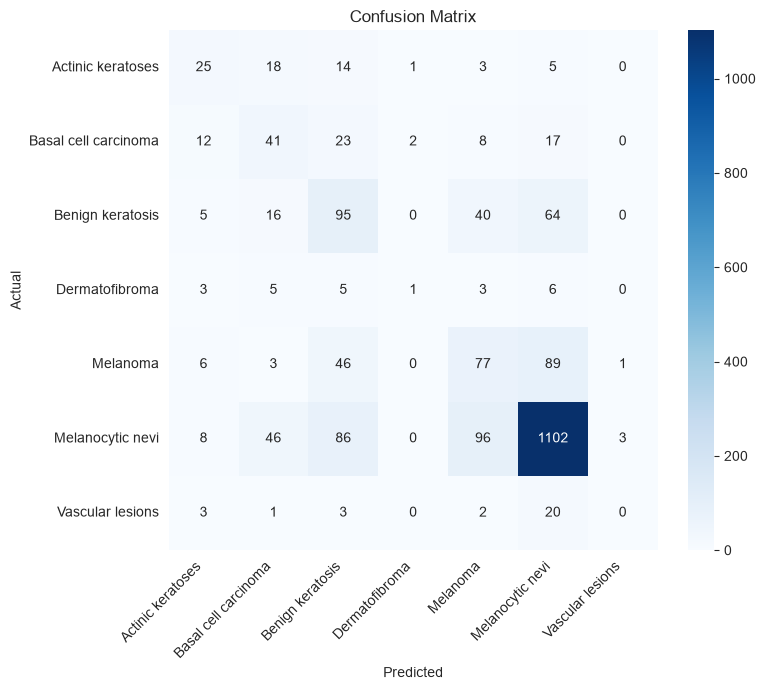

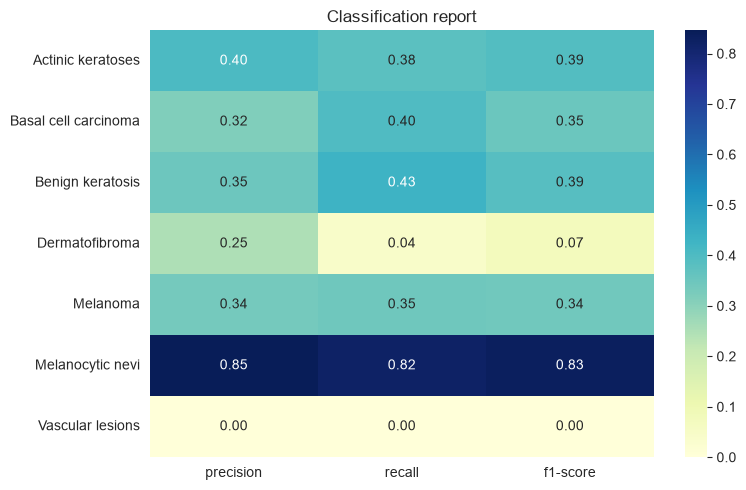

Macro ROC-AUC (OvR): 0.779
Malignant-vs-benign  sensitivity: 0.494   specificity: 0.859
Binary ROC-AUC: 0.709
Accuracy      : 66.92%


In [9]:
def save_show(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=150)   # save BEFORE show
    plt.show(); plt.close()

# Confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); save_show('confusion_matrix.png')

# Per-class precision / recall / F1
rep = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
rdf = pd.DataFrame({m: [rep[c][m] for c in class_names] for m in ['precision', 'recall', 'f1-score']},
                   index=class_names)
plt.figure(figsize=(8, 5)); sns.heatmap(rdf, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Classification report'); save_show('classification_report.png')

# Multiclass ROC-AUC (one-vs-rest)
scores = model.decision_function(X_test)
y_bin = label_binarize(y_test, classes=range(len(class_names)))
print(f"Macro ROC-AUC (OvR): {roc_auc_score(y_bin, scores, average='macro'):.3f}")

# Malignant vs benign view of the same predictions
mal = np.array([c in MALIGNANT for c in class_codes])
yt_b, yp_b = mal[y_test], mal[y_pred]
tn, fp, fn, tp = confusion_matrix(yt_b, yp_b).ravel()
print(f"Malignant-vs-benign  sensitivity: {tp/(tp+fn):.3f}   specificity: {tn/(tn+fp):.3f}")
print(f"Binary ROC-AUC: {roc_auc_score(yt_b, scores[:, mal].max(1)):.3f}")
from sklearn.metrics import  accuracy_score
accuracy=accuracy_score(y_test, y_pred)*100
print(f"Accuracy      : {accuracy:.2f}%")

## 6. Predicting on a New Image

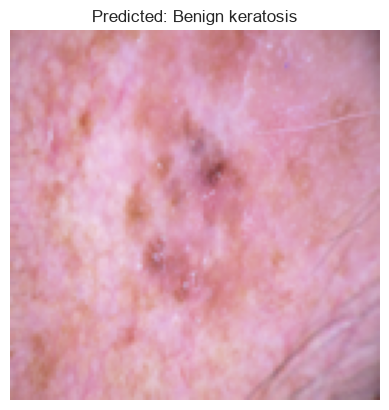

np.str_('Benign keratosis')

In [7]:
def classify_image(image_path, show=True):
    saved = joblib.load(os.path.join(OUTPUT_DIR, "skin_cancer_svm_model.pkl"))
    m, names = saved['model'], saved['class_names']
    img = Image.open(image_path).convert("RGB").resize(IMG_SIZE)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    pred = m.predict(extract_features(arr).reshape(1, -1))[0]
    if show:
        plt.imshow(img); plt.axis('off'); plt.title(f"Predicted: {names[pred]}")
        plt.savefig(os.path.join(OUTPUT_DIR, f"predicted_{os.path.basename(image_path)}"), dpi=150)
        plt.show()
    return names[pred]

classify_image(test_df['path'].iloc[0])